# Prototype 3 — Forward Return Analysis

Prototypes 1 and 2 found that large single-day declines were followed by a 5% recovery within ten trading days more often than matched ordinary trading days.

Prototype 3 moves beyond the hit-rate measure and examines the **actual distribution of returns after a large-drop event**.

**Hypothesis 3**: US large-cap stocks that fall by at least 8% in one trading day exhibit stronger subsequent return behaviour than matched ordinary trading days across multiple forward horizons.

### Parameters

- **Event**: Daily close-to-close return ≤ -8%
- **Control Day**: Any trading day where the daily return is > -8%
- **Universe**: The same ten large-cap US equities used in Prototypes 1 and 2
- **Historical Period**: 01 January 2016 to 01 January 2026
- **Forward Horizons**: 1, 3, 5 and 10 trading days
- **Control Matching**: Each simulated control sample contains the same number of observations for each stock as the event sample
- **Number of Control Simulations**: 1,000
- **Primary Metrics**:
    - Mean forward return
    - Median forward return
    - Percentage of observations with a positive forward return
- **Distribution Metrics**:
    - 25th and 75th percentiles
    - Best and worst forward returns
- **10-Day Path Metrics**:
    - Maximum return reached within the next ten trading days
    - Minimum return reached within the next ten trading days

> **Important:** Returns in this notebook are still measured from the event-day adjusted closing price. This is appropriate for studying post-event behaviour, but it is not yet a realistic trading entry rule. Prototype 4 will move to next-day opening prices when the first strategy backtest is constructed.

## Import Libraries

In [1]:
# If yfinance is not installed, uncomment the next line:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Recreate the Prototype Dataset

In [2]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "JPM", "JNJ", "XOM", "WMT", "NVDA"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

# Download historical stock data from Yahoo! Finance
prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=True
)

prices.head()

[*********************100%***********************]  10 of 10 completed


Price       Adj Close                                                          \
Ticker           AAPL       AMZN      GOOGL        JNJ        JPM        META   
Date                                                                            
2016-01-04  23.688667  31.849501  37.614075  74.967804  48.184071  101.330162   
2016-01-05  23.095049  31.689501  37.717594  75.281181  48.267376  101.835716   
2016-01-06  22.643089  31.632500  37.608627  74.900658  47.570587  102.073639   
2016-01-07  21.687449  30.396999  36.700771  74.027740  45.646870   97.067589   
2016-01-08  21.802122  30.352501  36.201019  73.236862  44.624413   96.482719   

Price                                                  ...     Volume  \
Ticker           MSFT      NVDA        WMT        XOM  ...       AAPL   
Date                                                   ...              
2016-01-04  47.680965  0.788626  16.966856  49.002308  ...  270597600   
2016-01-05  47.898479  0.801294  17.369913  49.419846  ...  223164000   
2016-01-06  47.028412  0.768161  17.543833  49.008633  ...  273829600   
2016-01-07  45.392628  0.737708  17.952404  48.224216  ...  324377600   
2016-01-08  45.531841  0.721872  17.541071  47.249977  ...  283192000   

Price                                                                    \
Ticker           AMZN     GOOGL       JNJ       JPM      META      MSFT   
Date                                                                      
2016-01-04  186290000  67382000  12722800  25393200  37912400  53778000   
2016-01-05  116452000  45216000   6467200  16566700  23258200  34079700   
2016-01-06  106584000  48206000   7733800  22961500  25096200  39518900   
2016-01-07  141498000  63132000   9433100  27630900  45172900  56564900   
2016-01-08  110258000  47506000   9766700  22373300  35402300  48754000   

Price                                      
Ticker           NVDA       WMT       XOM  
Date                                       
2016-01-04  358076000  35967600  20400100  
2016-01-05  490272000  39978000  11993500  
2016-01-06  449344000  49693800  18826900  
2016-01-07  645304000  79290000  21263800  
2016-01-08  398472000  53303700  19033600  

[5 rows x 60 columns]

In [3]:
# Extract adjusted closing prices
adj_close = prices["Adj Close"].copy()

# Calculate the percentage change from the previous trading day's adjusted close
daily_returns = adj_close.pct_change()

daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,WMT,XOM
Date,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.025059,-0.005024,0.002752,0.004180,0.001729,0.004989,0.004562,0.016064,0.023756,0.008521
2016-01-06,-0.019570,-0.001799,-0.002889,-0.005055,-0.014436,0.002336,-0.018165,-0.041350,0.010013,-0.008321
2016-01-07,-0.042205,-0.039058,-0.024140,-0.011654,-0.040439,-0.049044,-0.034783,-0.039644,0.023289,-0.016006
2016-01-08,0.005288,-0.001464,-0.013617,-0.010684,-0.022399,-0.006025,0.003067,-0.021466,-0.022912,-0.020202


## Recreate the Large-Drop Event Sample

In [4]:
# A qualifying event is a daily decline of 8% or more
drop_threshold = -0.08

# Convert the wide return table into long format:
# one row = one date + one ticker + one daily return
events = (
    daily_returns
    .stack()
    .reset_index()
)

events.columns = ["Date", "Ticker", "Daily_Return"]

# Keep only qualifying large-drop observations
events = events[
    events["Daily_Return"] <= drop_threshold
].copy()

# Sort chronologically for readability
events = events.sort_values("Date").reset_index(drop=True)

# Record the adjusted closing price on the event day
events["Start_Price"] = events.apply(
    lambda row: adj_close.loc[row["Date"], row["Ticker"]],
    axis=1
)

print(f"Number of large-drop events before forward-window filtering: {len(events)}")
events.head(10)

Number of large-drop events before forward-window filtering: 60


,Date,Ticker,Daily_Return,Start_Price
0,2017-02-23,NVDA,-0.092723,2.474879
1,2018-02-05,NVDA,-0.084875,5.276872
2,2018-02-20,WMT,-0.101832,27.425871
3,2018-07-26,META,-0.189609,174.725647
4,2018-10-24,NVDA,-0.097937,4.932814
5,2018-11-16,NVDA,-0.187559,4.067511
6,2018-11-19,NVDA,-0.119990,3.579450
7,2018-12-14,JNJ,-0.100379,107.526047
8,2019-01-03,AAPL,-0.099607,33.707932
9,2019-01-28,NVDA,-0.138245,3.417376


## Calculate Forward Returns

For each large-drop event:

**Where is the stock 1, 3, 5 and 10 trading days later?**

A forward return is calculated as:

\[
\text{Forward Return} =
\frac{\text{Future Price} - \text{Starting Price}}
{\text{Starting Price}}
\]

For example, `Forward_Return_5D = 0.06` means the stock closed 6% above the event-day price five trading days later.

The function also records the **highest** and **lowest** return reached at any closing price during the next ten trading days. These path metrics help show how much upside and downside occurred inside the window, rather than looking only at the final tenth-day price.

In [5]:
# Forward horizons to study
horizons = [1, 3, 5, 10]
forward_days = 10

def calculate_forward_metrics(row):

    ticker = row["Ticker"]
    start_date = row["Date"]
    start_price = row["Start_Price"]

    # Find the integer row position of the starting date
    start_index = adj_close.index.get_loc(start_date)

    # Create a dictionary with NaN values as a default
    results = {
        f"Forward_Return_{h}D": np.nan
        #Forward_Return_1D: NAN, Forward_Return_3D: NAN, Forward_Return_5D: NAN, Forward_Return_10D: NAN
        for h in horizons
    }

    results["Max_Return_Within_10D"] = np.nan #tracks maximum return over the 10 day forward return period 
    results["Min_Return_Within_10D"] = np.nan #tracks minimum return over the 10 day forward return period 

    # We need a full ten future trading days for a fair comparison.
    # If they do not exist, return the missing-value dictionary.
    if start_index + forward_days >= len(adj_close.index):
        return pd.Series(results)

    ticker_prices = adj_close[ticker]

    # Calculate the return at each exact forward horizon
    for h in horizons:
        future_price = ticker_prices.iloc[start_index + h]

        results[f"Forward_Return_{h}D"] = (
            future_price - start_price
        ) / start_price

    # Select every closing price in the next ten trading days
    future_window = ticker_prices.iloc[
        start_index + 1 : start_index + 1 + forward_days
    ]

    # Convert each future price into a return relative to the starting price
    future_window_returns = (
        future_window - start_price
    ) / start_price

    # Highest and lowest return reached anywhere inside the 10-day window
    results["Max_Return_Within_10D"] = future_window_returns.max()
    results["Min_Return_Within_10D"] = future_window_returns.min()

    return pd.Series(results)

The function is now applied to every large-drop event.

Observations without a complete ten-trading-day forward window are removed so that every event is evaluated using the same amount of future information.

In [6]:
# Apply the forward-return function to every large-drop event
event_forward_metrics = events.apply(
    calculate_forward_metrics,
    axis=1
)

# Add the newly calculated columns to the event dataframe
events = pd.concat(
    [events, event_forward_metrics],
    axis=1
)

# Keep only observations with a complete 10-day forward window
valid_events = events.dropna(
    subset=["Forward_Return_10D"]
).copy()

print(f"Number of valid large-drop events: {len(valid_events)}")
valid_events.head(10)

Number of valid large-drop events: 60


,Date,Ticker,Daily_Return,Start_Price,Forward_Return_1D,Forward_Return_3D,Forward_Return_5D,Forward_Return_10D,Max_Return_Within_10D,Min_Return_Within_10D
0,2017-02-23,NVDA,-0.092723,2.474879,0.009653,0.009852,-0.014828,-0.019405,0.039009,-0.028062
1,2018-02-05,NVDA,-0.084875,5.276872,0.055592,0.017876,0.067057,0.165559,0.165559,0.017876
2,2018-02-20,WMT,-0.101832,27.425871,-0.027521,-0.012963,-0.027521,-0.053660,-0.010520,-0.056742
3,2018-07-26,META,-0.189609,174.725647,-0.007773,-0.020878,0.000624,0.038749,0.053500,-0.029502
4,2018-10-24,NVDA,-0.097937,4.932814,0.042275,-0.069154,0.057269,0.072113,0.093777,-0.069154
5,2018-11-16,NVDA,-0.187559,4.067511,-0.119990,-0.119929,-0.069208,0.035153,0.035153,-0.119990
6,2018-11-19,NVDA,-0.119990,3.579450,0.030270,0.002073,0.062405,0.086850,0.176297,0.000069
7,2018-12-14,JNJ,-0.100379,107.526047,-0.029023,-0.040526,-0.036917,-0.029699,-0.019399,-0.076391
8,2019-01-03,AAPL,-0.099607,33.707932,0.042689,0.060201,0.081651,0.096139,0.096139,0.040368
9,2019-01-28,NVDA,-0.138245,3.417376,-0.046446,0.041591,0.080936,0.061155,0.108615,-0.046446


## Summarise Returns After Large-Drop Events

In [7]:
def summarise_forward_returns(sample, group_name):

    summary_rows = []

    for h in horizons:
        return_column = f"Forward_Return_{h}D"
        returns = sample[return_column].dropna()

        summary_rows.append({
            "Group": group_name,
            "Horizon_Days": h,
            "Mean_Return": returns.mean(),
            "Median_Return": returns.median(),
            "Positive_Rate": (returns > 0).mean(),
            "P25": returns.quantile(0.25),
            "P75": returns.quantile(0.75),
            "Worst_Return": returns.min(),
            "Best_Return": returns.max()
        })

    return pd.DataFrame(summary_rows)

event_summary = summarise_forward_returns(
    valid_events,
    group_name="Large-Drop Events"
)

event_summary.style.format({
    "Mean_Return": "{:.2%}",
    "Median_Return": "{:.2%}",
    "Positive_Rate": "{:.1%}",
    "P25": "{:.2%}",
    "P75": "{:.2%}",
    "Worst_Return": "{:.2%}",
    "Best_Return": "{:.2%}"
})

,Group,Horizon_Days,Mean_Return,Median_Return,Positive_Rate,P25,P75,Worst_Return,Best_Return
0,Large-Drop Events,1,2.10%,1.90%,61.7%,-1.91%,4.37%,-12.00%,18.01%
1,Large-Drop Events,3,-0.96%,-1.15%,41.7%,-4.37%,2.28%,-15.14%,14.62%
2,Large-Drop Events,5,-1.23%,-1.44%,45.0%,-6.63%,1.80%,-17.61%,15.31%
3,Large-Drop Events,10,2.65%,4.26%,60.0%,-3.97%,7.96%,-24.87%,35.23%


### What the Summary Statistics Mean

- **Mean Return**: the arithmetic average return across all observations
- **Median Return**: the middle observation after the returns are ordered; this is less sensitive to extreme winners or losers than the mean
- **Positive Rate**: the percentage of observations whose forward return is above 0%
- **P25**: 25% of observations performed worse than this value
- **P75**: 25% of observations performed better than this value
- **Worst / Best Return**: the most extreme outcomes in the event sample

Looking at the mean and median together is especially useful. If the mean is strongly positive but the median is weak, a small number of unusually large winners may be pulling the average upward.

## Construct the Matched Ordinary-Day Baseline

In [8]:
# Count the number of large-drop events contributed by each ticker
event_counts = (
    valid_events["Ticker"]
    .value_counts()
    .reindex(tickers)
    .fillna(0)
    .astype(int)
)

# Store the eligible ordinary/control dates for each stock
eligible_control_dates = {}

for ticker in tickers:

    ticker_returns = daily_returns[ticker].dropna()

    # Ordinary days are days that did not meet the -8% event threshold
    ticker_control_dates = ticker_returns[
        ticker_returns > drop_threshold
    ].index

    # Keep only dates with a complete ten-trading-day forward window
    ticker_control_dates = [
        date
        for date in ticker_control_dates
        if adj_close.index.get_loc(date) + forward_days < len(adj_close.index)
    ]

    eligible_control_dates[ticker] = ticker_control_dates

pd.Series({
    ticker: len(dates)
    for ticker, dates in eligible_control_dates.items()
})

AAPL     2498
MSFT     2501
AMZN     2498
GOOGL    2499
META     2493
JPM      2498
JNJ      2502
XOM      2498
WMT      2499
NVDA     2484
dtype: int64

The control design remains the same as Prototype 2.

Each simulated control sample contains exactly the same number of observations for each ticker as the large-drop event sample. This prevents the comparison from being distorted simply because one stock, such as NVDA, contributes more event observations than another.

In [9]:
def build_control_sample(seed):

    rng = np.random.default_rng(seed)
    control_rows = []

    for ticker in tickers:

        number_of_events = event_counts[ticker]

        # Skip a ticker if it contributed no valid events
        if number_of_events == 0:
            continue

        sampled_dates = rng.choice(
            eligible_control_dates[ticker],
            size=number_of_events,
            replace=False
        )

        for date in sampled_dates:

            date = pd.Timestamp(date)

            control_rows.append({
                "Date": date,
                "Ticker": ticker,
                "Daily_Return": daily_returns.loc[date, ticker],
                "Start_Price": adj_close.loc[date, ticker]
            })

    control_sample = pd.DataFrame(control_rows)

    # Calculate the same forward metrics used for the event observations
    control_forward_metrics = control_sample.apply(
        calculate_forward_metrics,
        axis=1
    )

    control_sample = pd.concat(
        [control_sample, control_forward_metrics],
        axis=1
    )

    return control_sample

In [10]:
# Inspect one reproducible control sample before running all simulations
example_control = build_control_sample(seed=42)

print(f"Number of observations in example control sample: {len(example_control)}")
example_control.head(10)

Number of observations in example control sample: 60


,Date,Ticker,Daily_Return,Start_Price,Forward_Return_1D,Forward_Return_3D,Forward_Return_5D,Forward_Return_10D,Max_Return_Within_10D,Min_Return_Within_10D
0,2023-09-13,AAPL,-0.011855,171.885239,0.008783,0.021583,0.007347,-0.021698,0.027897,-0.021698
1,2020-05-15,AAPL,-0.005912,74.419167,0.023561,0.037438,0.036333,0.045952,0.045952,0.017647
2,2022-07-07,AAPL,0.024000,143.346313,0.004715,-0.003348,0.014486,0.061497,0.061497,-0.010112
3,2016-11-18,AAPL,0.001000,25.298363,0.015174,0.010631,0.013720,-0.008632,0.015810,-0.008632
4,2020-04-27,AAPL,0.000707,68.299339,-0.016209,0.037539,0.035279,0.115453,0.115453,-0.016209
5,2016-12-08,MSFT,-0.005866,54.540871,0.015735,0.032290,0.025733,0.041632,0.042780,0.015735
6,2021-03-31,MSFT,0.016907,225.322250,0.027909,0.051279,0.074140,0.100649,0.100649,0.027909
7,2021-02-08,AMZN,-0.008714,166.147003,-0.005399,-0.018300,-0.016248,-0.038653,0.001592,-0.042793
8,2023-02-16,AMZN,-0.029755,98.150002,-0.009679,-0.024045,-0.047376,-0.033113,-0.009679,-0.061335
9,2023-07-26,AMZN,-0.007589,128.149994,0.000780,0.043153,0.000468,0.075693,0.109793,0.000468


## Repeat the Control Experiment 1,000 Times

In [11]:
n_simulations = 1000

simulation_rows = []
excursion_rows = []

for simulation in range(n_simulations):

    control_sample = build_control_sample(
        seed=simulation
    )

    # Summarise exact forward returns at each horizon
    for h in horizons:

        returns = control_sample[
            f"Forward_Return_{h}D"
        ].dropna()

        simulation_rows.append({
            "Simulation": simulation,
            "Horizon_Days": h,
            "Mean_Return": returns.mean(),
            "Median_Return": returns.median(),
            "Positive_Rate": (returns > 0).mean()
        })

    # Also summarise the highest and lowest points reached
    # inside each observation's ten-day path
    excursion_rows.append({
        "Simulation": simulation,
        "Mean_Max_Return_Within_10D": control_sample[
            "Max_Return_Within_10D"
        ].mean(),
        "Mean_Min_Return_Within_10D": control_sample[
            "Min_Return_Within_10D"
        ].mean()
    })

control_simulations = pd.DataFrame(simulation_rows)
control_excursions = pd.DataFrame(excursion_rows)

control_simulations.head()

,Simulation,Horizon_Days,Mean_Return,Median_Return,Positive_Rate
0,0,1,0.002982,0.005728,0.566667
1,0,3,0.013574,0.012053,0.616667
2,0,5,0.007261,0.006558,0.600000
3,0,10,-0.002396,-0.001992,0.483333
4,1,1,-0.000768,0.000523,0.500000


## Compare Large-Drop Events With Ordinary Trading Days

For each forward horizon, the large-drop event result is compared with the average result across the 1,000 matched control simulations.

The **95% control range** describes the middle 95% of simulated control-sample mean returns.

The **exceedance rate** is the percentage of control simulations whose mean return was equal to or greater than the observed large-drop event mean return. This is an intuitive simulation comparison rather than a formal causal test.

In [12]:
comparison_rows = []

for h in horizons:

    # Event statistics at this horizon
    event_row = event_summary[
        event_summary["Horizon_Days"] == h
    ].iloc[0]

    # All simulation-level control results at this horizon
    control_h = control_simulations[
        control_simulations["Horizon_Days"] == h
    ]

    event_mean = event_row["Mean_Return"]

    comparison_rows.append({
        "Horizon_Days": h,
        "Event_Mean_Return": event_mean,
        "Control_Mean_Return": control_h["Mean_Return"].mean(),
        "Mean_Return_Difference": (
            event_mean - control_h["Mean_Return"].mean()
        ),
        "Event_Median_Return": event_row["Median_Return"],
        "Control_Median_Return": control_h["Median_Return"].mean(),
        "Event_Positive_Rate": event_row["Positive_Rate"],
        "Control_Positive_Rate": control_h["Positive_Rate"].mean(),
        "Control_Mean_2.5pct": control_h["Mean_Return"].quantile(0.025),
        "Control_Mean_97.5pct": control_h["Mean_Return"].quantile(0.975),
        "Control_Sims_At_Or_Above_Event_Mean": (
            control_h["Mean_Return"] >= event_mean
        ).mean()
    })

comparison = pd.DataFrame(comparison_rows)

comparison.style.format({
    "Event_Mean_Return": "{:.2%}",
    "Control_Mean_Return": "{:.2%}",
    "Mean_Return_Difference": "{:.2%}",
    "Event_Median_Return": "{:.2%}",
    "Control_Median_Return": "{:.2%}",
    "Event_Positive_Rate": "{:.1%}",
    "Control_Positive_Rate": "{:.1%}",
    "Control_Mean_2.5pct": "{:.2%}",
    "Control_Mean_97.5pct": "{:.2%}",
    "Control_Sims_At_Or_Above_Event_Mean": "{:.1%}"
})

,Horizon_Days,Event_Mean_Return,Control_Mean_Return,Mean_Return_Difference,Event_Median_Return,Control_Median_Return,Event_Positive_Rate,Control_Positive_Rate,Control_Mean_2.5pct,Control_Mean_97.5pct,Control_Sims_At_Or_Above_Event_Mean
0,1,2.10%,0.14%,1.96%,1.90%,0.13%,61.7%,53.6%,-0.48%,0.71%,0.0%
1,3,-0.96%,0.45%,-1.41%,-1.15%,0.44%,41.7%,56.5%,-0.57%,1.43%,99.5%
2,5,-1.23%,0.77%,-1.99%,-1.44%,0.72%,45.0%,58.3%,-0.52%,1.93%,99.9%
3,10,2.65%,1.51%,1.14%,4.26%,1.38%,60.0%,60.6%,-0.28%,3.22%,9.5%


### Compare the 10-Day Path Extremes

In [13]:
# Average highest and lowest returns reached within ten days for the actual large-drop events
event_mean_max = valid_events[
    "Max_Return_Within_10D"
].mean()

event_mean_min = valid_events[
    "Min_Return_Within_10D"
].mean()

# Average corresponding values across the 1,000 matched control simulations
control_mean_max = control_excursions[
    "Mean_Max_Return_Within_10D"
].mean()

control_mean_min = control_excursions[
    "Mean_Min_Return_Within_10D"
].mean()

excursion_comparison = pd.DataFrame({
    "Metric": [
        "Average maximum return reached within 10 days",
        "Average minimum return reached within 10 days"
    ],
    "Large_Drop_Events": [
        event_mean_max,
        event_mean_min
    ],
    "Matched_Control": [
        control_mean_max,
        control_mean_min
    ]
})

excursion_comparison["Difference"] = (
    excursion_comparison["Large_Drop_Events"]
    - excursion_comparison["Matched_Control"]
)

excursion_comparison.style.format({
    "Large_Drop_Events": "{:.2%}",
    "Matched_Control": "{:.2%}",
    "Difference": "{:.2%}"
})

,Metric,Large_Drop_Events,Matched_Control,Difference
0,Average maximum return reached within 10 days,7.91%,4.60%,3.31%
1,Average minimum return reached within 10 days,-6.36%,-3.03%,-3.33%


## Visualise the Forward-Return Comparison

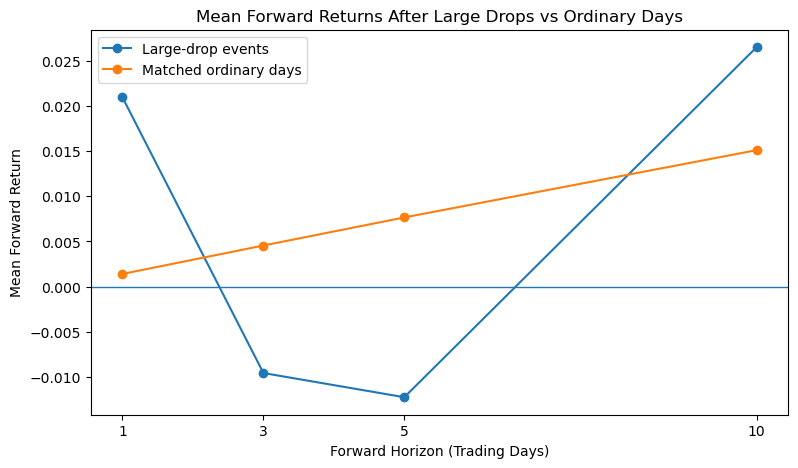

In [14]:
# Extract the series needed for the chart
plot_horizons = comparison["Horizon_Days"]
event_means = comparison["Event_Mean_Return"]
control_means = comparison["Control_Mean_Return"]

plt.figure(figsize=(9, 5))

plt.plot(
    plot_horizons,
    event_means,
    marker="o",
    label="Large-drop events"
)

plt.plot(
    plot_horizons,
    control_means,
    marker="o",
    label="Matched ordinary days"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Forward Horizon (Trading Days)")
plt.ylabel("Mean Forward Return")
plt.title("Mean Forward Returns After Large Drops vs Ordinary Days")
plt.xticks(horizons)
plt.legend()

plt.show()

The first chart shows how the average forward return develops through time for the large-drop event sample compared with matched ordinary trading days.

A persistent gap across several horizons would be more convincing than a difference that appears only at one isolated horizon.

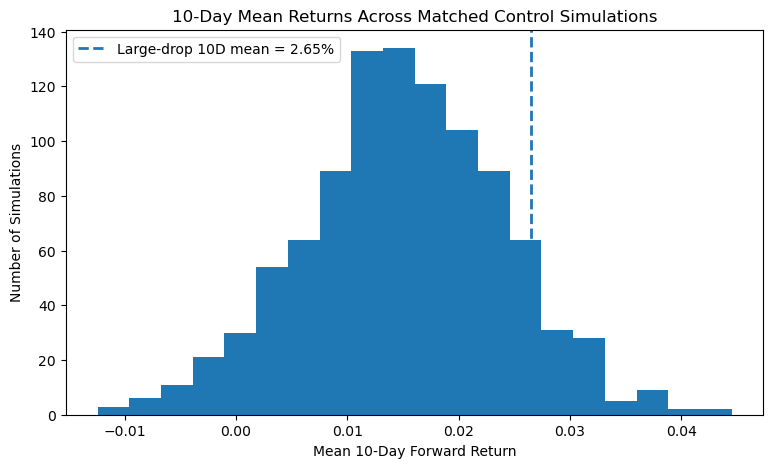

In [15]:
# Compare the observed 10-day event mean with the distribution
# of 10-day mean returns from the 1,000 control simulations

event_10d_mean = comparison.loc[
    comparison["Horizon_Days"] == 10,
    "Event_Mean_Return"
].iloc[0]

control_10d_means = control_simulations.loc[
    control_simulations["Horizon_Days"] == 10,
    "Mean_Return"
]

plt.figure(figsize=(9, 5))

plt.hist(
    control_10d_means,
    bins=20
)

plt.axvline(
    event_10d_mean,
    linestyle="--",
    linewidth=2,
    label=f"Large-drop 10D mean = {event_10d_mean:.2%}"
)

plt.xlabel("Mean 10-Day Forward Return")
plt.ylabel("Number of Simulations")
plt.title("10-Day Mean Returns Across Matched Control Simulations")
plt.legend()

plt.show()

## Results

The forward-return analysis reveals that the behaviour following a large single-day decline is not a simple, continuous recovery. Instead, the results suggest a more volatile pattern consisting of an immediate rebound, a subsequent retracement, and some evidence of recovery over the longer ten-day horizon.

### Immediate Rebound

The strongest effect occurs one trading day after the large-drop event. Stocks in the event sample generated a mean one-day forward return of **2.10%**, compared with **0.14%** across matched ordinary trading days. The median event return was similarly positive at **1.90%**, while **61.7%** of event observations produced a positive return.

None of the 1,000 matched control simulations generated a mean one-day return equal to or greater than the observed event mean. This provides strong evidence that the immediate post-drop rebound differs meaningfully from typical short-term price behaviour within this sample.

### Reversal Over the Three- to Five-Day Horizon

The initial rebound was not sustained over the following several trading days.

After three days, the event sample produced a mean return of **-0.96%**, compared with **0.45%** for matched ordinary days. After five days, this gap widened further, with event returns averaging **-1.23%** compared with **0.77%** for the matched control.

Only **41.7%** and **45.0%** of event observations were positive at the three- and five-day horizons respectively, compared with control positive rates of **56.5%** and **58.3%**.

Furthermore, **99.5%** of matched control simulations produced a three-day mean return equal to or greater than the event result, increasing to **99.9%** at the five-day horizon. The evidence therefore suggests that the immediate rebound is frequently followed by a period of relative weakness rather than a smooth continuation upward.

### Ten-Day Recovery

By ten trading days, performance in the event sample had recovered. The mean ten-day return was **2.65%**, compared with **1.51%** for matched ordinary trading days, while the median event return reached **4.26%**, substantially above the control median of **1.38%**.

Approximately **60.0%** of large-drop events produced a positive ten-day return, broadly similar to the **60.6%** positive rate observed in the control simulations.

The ten-day event mean remained within the 95% range of control-simulation means, and **9.5%** of control simulations generated a mean return equal to or greater than the observed event result. The ten-day recovery therefore appears suggestive, but considerably weaker than the immediate one-day rebound.

### Increased Post-Event Volatility

Large-drop events also exhibited substantially greater price movement in both directions during the subsequent ten trading days.

The average maximum return reached within the ten-day window was **7.91%** following large drops, compared with **4.60%** for matched ordinary days. However, the average minimum return was also considerably lower at **-6.36%**, compared with **-3.03%** for ordinary trading days.

Large-drop events therefore experienced approximately **3.31 percentage points of additional upside**, but also approximately **3.33 percentage points of additional downside**.

This suggests that the higher 5% recovery rate observed in the earlier event study should not be interpreted as evidence of a smooth or low-risk recovery. Instead, large-drop events appear to be followed by substantially increased short-term volatility, creating both greater rebound opportunities and greater downside risk.

### Implications for the Trading Strategy

The results suggest that the strongest potential trading signal may occur immediately after the large-drop event rather than through a passive three- to five-day holding strategy.

However, the one-day forward returns measured in this notebook are calculated from the event-day closing price. A real trading strategy cannot know the final daily decline until the trading session has ended, meaning that a realistic position would generally be entered no earlier than the following trading day's opening price.

The next prototype will therefore test whether the observed rebound remains exploitable after introducing realistic entry timing. It will construct explicit trades using next-day opening prices and compare alternative exit rules, including short holding periods, take-profit targets and maximum holding periods.

The increased downside observed during the ten-day recovery window also indicates that position sizing, stop-loss rules and portfolio exposure will become important components of the eventual trading system.

### Next Step

Prototype 4 will convert the statistical pattern into the first **realistic trading-rule backtest**.

Unlike this descriptive event study, the strategy backtest will not assume that a position can be entered at the same closing price used to identify the -8% signal. A signal will be generated after the large-drop day closes, and the first realistic entry will occur at the **next trading day's opening price**.

The backtest will then model explicit entry and exit rules, trade-level profit and loss, holding periods and portfolio behaviour.